# **Fake News Model Training**

# All Imports Here

In [44]:
import os

os.chdir('d:\\GitHub\\TECH_405_Fake_News_Indicator_ANN')
os.getcwd()

'd:\\GitHub\\TECH_405_Fake_News_Indicator_ANN'

In [45]:
import pandas as pd
from Data_Preprocessor.preprocessor import DataPreprocessor
import re
import torch
import torch.nn as nn
import copy
import json

from collections import Counter
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence


# Dataset Import

In [46]:
df = pd.read_csv('data\\news.csv')
df = df.reset_index()
df = df.drop(['index', 'Unnamed: 0'], axis=1)

In [47]:
df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [48]:
df.shape

(6335, 3)

In [49]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(29)

In [51]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Applying Preprocessor

In [52]:
dp = DataPreprocessor(df, cols=['title', 'text'])
df_clean = dp.run_preprocessor()

In [53]:
df_clean.head()

,title,title_clean,text,text_clean
0,you can smell hillary s fear,"[smell, hillary, fear]",daniel greenfield a shillman journalism fellow...,"[daniel, greenfield, shillman, journalism, fel..."
1,watch the exact moment paul ryan committed pol...,"[watch, exact, moment, paul, ryan, committed, ...",google pinterest digg linkedin reddit stumbleu...,"[google, pinterest, digg, linkedin, reddit, st..."
2,kerry to go to paris in gesture of sympathy,"[kerry, go, paris, gesture, sympathy]",u s secretary of state john f kerry said monda...,"[u, secretary, state, john, f, kerry, said, mo..."
3,bernie supporters on twitter erupt in anger ag...,"[bernie, supporter, twitter, erupt, anger, dnc...",kaydee king november the lesson from tonight s...,"[kaydee, king, november, lesson, tonight, dem,..."
4,the battle of new york why this primary matters,"[battle, new, york, primary, matter]",it s primary day in new york and front runners...,"[primary, day, new, york, front, runner, hilla..."


In [54]:
df_clean.isnull().sum()

title          0
title_clean    0
text           0
text_clean     0
dtype: int64

In [55]:
# dropping unnecessary cols
df_clean.drop(['title', 'text'], axis = 1, inplace=True)
df_clean['combined_text'] = dp.combine_text()
df_clean['label'] = df['label'].copy()
df_clean['label'] = df_clean['label'].map({'FAKE': 0, 'REAL': 1})
df_clean.head()     

,title_clean,text_clean,combined_text,label
0,"[smell, hillary, fear]","[daniel, greenfield, shillman, journalism, fel...",smell hillary fear daniel greenfield shillman ...,0
1,"[watch, exact, moment, paul, ryan, committed, ...","[google, pinterest, digg, linkedin, reddit, st...",watch exact moment paul ryan committed politic...,0
2,"[kerry, go, paris, gesture, sympathy]","[u, secretary, state, john, f, kerry, said, mo...",kerry go paris gesture sympathy u secretary st...,1
3,"[bernie, supporter, twitter, erupt, anger, dnc...","[kaydee, king, november, lesson, tonight, dem,...",bernie supporter twitter erupt anger dnc tried...,0
4,"[battle, new, york, primary, matter]","[primary, day, new, york, front, runner, hilla...",battle new york primary matter primary day new...,1


# Modeling

## **Vocabulary**

In [56]:
def tokenize(text):
    # handles strings and token lists
    if isinstance(text, list):
        return [str(token).lower() for token in text]

    return re.findall(r"\b\w+\b", str(text).lower())

counter = Counter()

for text in df_clean["combined_text"]:
    counter.update(tokenize(text))

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for w, _ in counter.most_common(8000):
    vocab[w] = len(vocab)

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]

print("Counter:", counter.most_common(10))
print("Vocabulary size:", len(vocab))

Counter: [('trump', 23522), ('said', 21133), ('clinton', 18741), ('state', 15560), ('u', 13976), ('would', 12751), ('one', 12432), ('people', 11877), ('year', 10098), ('republican', 9750)]
Vocabulary size: 8002


## **Dataset and Dataloader**

In [57]:
class NewsDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.texts = dataframe["combined_text"].tolist()
        self.labels = dataframe["label"].astype(float).tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        tokens = tokenize(self.texts[index])

        token_ids = [
            self.vocab.get(token, UNK_IDX)
            for token in tokens
        ]

        if not token_ids:
            token_ids = [UNK_IDX]

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.float32)
        )


def collate_batch(batch):
    texts, labels = zip(*batch)

    lengths = torch.tensor(
        [len(text) for text in texts],
        dtype=torch.long
    )

    padded_texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=PAD_IDX
    )

    labels = torch.stack(labels)

    return padded_texts, lengths, labels

In [58]:
dataset = NewsDataset(df_clean, vocab)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_batch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_batch
)

## **RNN**

In [59]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, text, lengths):
        embedded = self.embedding(text)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        final_hidden = hidden[-1]
        logits = self.fc(self.dropout(final_hidden)).squeeze(-1)

        return logits


## **LSTM**

In [60]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.3,
        bidirectional=True
    ):
        super().__init__()

        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, text, lengths):
        embedded = self.embedding(text)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            final_hidden = torch.cat(
                (hidden[-2], hidden[-1]),
                dim=1
            )
        else:
            final_hidden = hidden[-1]

        logits = self.fc(self.dropout(final_hidden)).squeeze(-1)

        return logits


## **Train and Evaluate**

In [61]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

criterion = nn.BCEWithLogitsLoss()


def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for texts, lengths, labels in loader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(texts, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        # Helps prevent exploding gradients in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        predictions = (torch.sigmoid(logits) >= 0.5).float()

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )


def evaluate(model, loader, return_predictions=False):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for texts, lengths, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            logits = model(texts, lengths)
            loss = criterion(logits, labels)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

            all_probabilities.extend(probabilities.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    roc_auc = roc_auc_score(all_labels, all_probabilities)

    metrics = {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "roc_auc": roc_auc
    }

    if return_predictions:
        metrics["labels"] = all_labels
        metrics["probabilities"] = all_probabilities

    return metrics


## **Train Both Models**

In [62]:
rnn = RNNClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128
).to(device)

In [63]:
lstm = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    bidirectional=True
).to(device)

In [64]:
def train_model(model, model_name, epochs=10, learning_rate=0.001, weight_decay=0.0001):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    history = {
        "train_accuracy": [],
        "val_accuracy": [],
        "test_accuracy": [],
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
        "val_roc_auc": [],
        "test_roc_auc": []
    }
    best_checkpoint = {
        "epoch": 0,
        "val_roc_auc": -1,
        "state_dict": copy.deepcopy(model.state_dict())
    }

    print(f"Training {model_name}")

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer
        )

        val_metrics = evaluate(model, val_loader)
        test_metrics = evaluate(model, test_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["test_loss"].append(test_metrics["loss"])

        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["test_accuracy"].append(test_metrics["accuracy"])
        history["val_roc_auc"].append(val_metrics["roc_auc"])
        history["test_roc_auc"].append(test_metrics["roc_auc"])

        if val_metrics["roc_auc"] > best_checkpoint["val_roc_auc"]:
            best_checkpoint = {
                "epoch": epoch + 1,
                "val_roc_auc": val_metrics["roc_auc"],
                "state_dict": copy.deepcopy(model.state_dict())
            }

        print(
            f"{model_name} Epoch {epoch + 1:02d} | "
            f"Train Accuracy: {train_acc:.4f} | "
            f"Validation Accuracy: {val_metrics['accuracy']:.4f} | "
            f"Validation ROC-AUC: {val_metrics['roc_auc']:.4f} | "
            f"Test Accuracy: {test_metrics['accuracy']:.4f} | "
            f"Test ROC-AUC: {test_metrics['roc_auc']:.4f}"
        )

    model.load_state_dict(best_checkpoint["state_dict"])

    return history, best_checkpoint


epochs = 10

rnn_history, rnn_best_checkpoint = train_model(rnn, "RNN", epochs=epochs)
lstm_history, lstm_best_checkpoint = train_model(lstm, "LSTM", epochs=epochs)


Training RNN
RNN Epoch 01 | Train Accuracy: 0.6632 | Validation Accuracy: 0.7444 | Validation ROC-AUC: 0.8087 | Test Accuracy: 0.7453 | Test ROC-AUC: 0.8157
RNN Epoch 02 | Train Accuracy: 0.7829 | Validation Accuracy: 0.7286 | Validation ROC-AUC: 0.8197 | Test Accuracy: 0.7674 | Test ROC-AUC: 0.8429
RNN Epoch 03 | Train Accuracy: 0.8176 | Validation Accuracy: 0.7714 | Validation ROC-AUC: 0.8572 | Test Accuracy: 0.7896 | Test ROC-AUC: 0.8644
RNN Epoch 04 | Train Accuracy: 0.8563 | Validation Accuracy: 0.8127 | Validation ROC-AUC: 0.8767 | Test Accuracy: 0.8149 | Test ROC-AUC: 0.8880
RNN Epoch 05 | Train Accuracy: 0.8856 | Validation Accuracy: 0.7873 | Validation ROC-AUC: 0.8587 | Test Accuracy: 0.8275 | Test ROC-AUC: 0.8904
RNN Epoch 06 | Train Accuracy: 0.9106 | Validation Accuracy: 0.7873 | Validation ROC-AUC: 0.8579 | Test Accuracy: 0.8054 | Test ROC-AUC: 0.8848
RNN Epoch 07 | Train Accuracy: 0.9372 | Validation Accuracy: 0.8175 | Validation ROC-AUC: 0.8745 | Test Accuracy: 0.8228 | 

## **Visualize and Compare Model Accuracy**


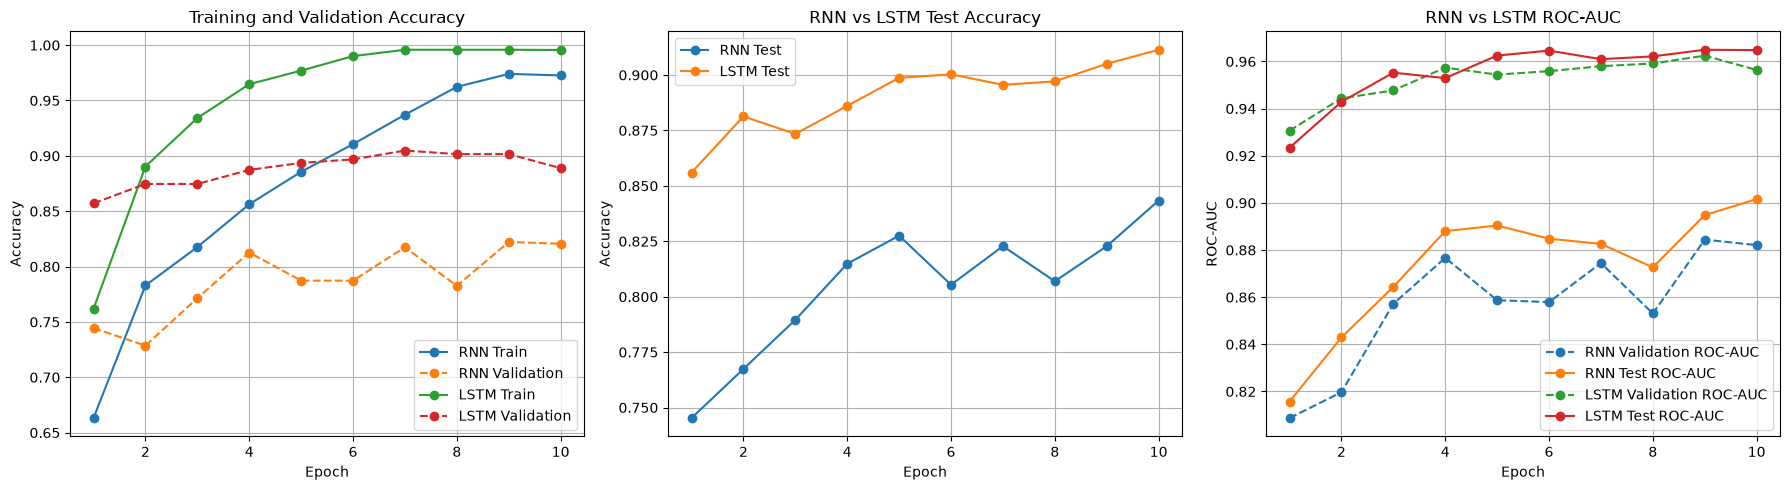

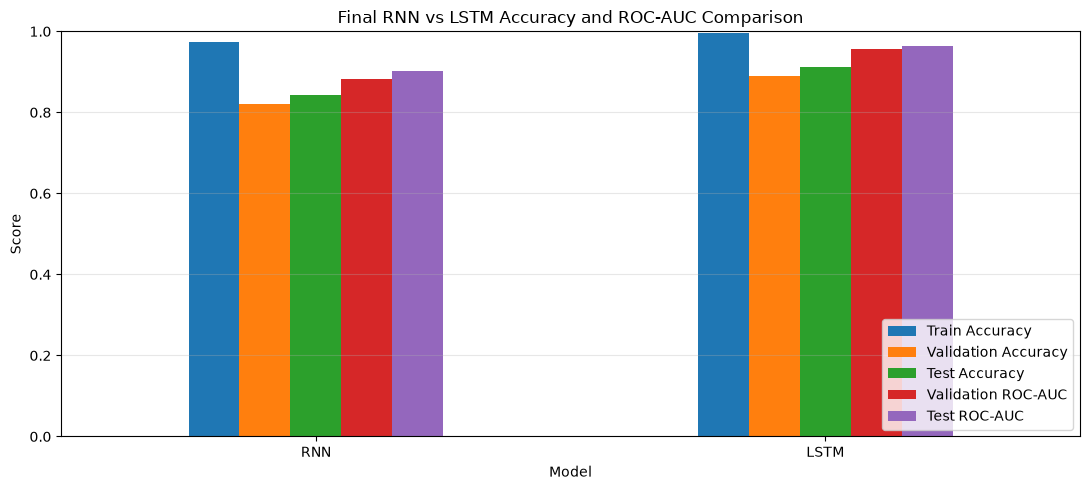

,Model,Best Epoch,Train Accuracy,Validation Accuracy,Test Accuracy,Validation ROC-AUC,Test ROC-AUC
0,RNN,9,0.972641,0.820635,0.843354,0.882079,0.901613
1,LSTM,9,0.995638,0.888889,0.911392,0.956391,0.964822


In [65]:
import matplotlib.pyplot as plt

model_histories = {
    "RNN": rnn_history,
    "LSTM": lstm_history
}

epoch_numbers = range(1, epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model_name, history in model_histories.items():
    axes[0].plot(
        epoch_numbers,
        history["train_accuracy"],
        marker="o",
        label=f"{model_name} Train"
    )
    axes[0].plot(
        epoch_numbers,
        history["val_accuracy"],
        marker="o",
        linestyle="--",
        label=f"{model_name} Validation"
    )
    axes[1].plot(
        epoch_numbers,
        history["test_accuracy"],
        marker="o",
        label=f"{model_name} Test"
    )
    axes[2].plot(
        epoch_numbers,
        history["val_roc_auc"],
        marker="o",
        linestyle="--",
        label=f"{model_name} Validation ROC-AUC"
    )
    axes[2].plot(
        epoch_numbers,
        history["test_roc_auc"],
        marker="o",
        label=f"{model_name} Test ROC-AUC"
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("RNN vs LSTM Test Accuracy")
axes[1].legend()
axes[1].grid(True)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("RNN vs LSTM ROC-AUC")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

final_accuracy_comparison = pd.DataFrame({
    "Model": list(model_histories.keys()),
    "Best Epoch": [rnn_best_checkpoint["epoch"], lstm_best_checkpoint["epoch"]],
    "Train Accuracy": [history["train_accuracy"][-1] for history in model_histories.values()],
    "Validation Accuracy": [history["val_accuracy"][-1] for history in model_histories.values()],
    "Test Accuracy": [history["test_accuracy"][-1] for history in model_histories.values()],
    "Validation ROC-AUC": [history["val_roc_auc"][-1] for history in model_histories.values()],
    "Test ROC-AUC": [history["test_roc_auc"][-1] for history in model_histories.values()]
})

ax = final_accuracy_comparison.set_index("Model")[
    ["Train Accuracy", "Validation Accuracy", "Test Accuracy", "Validation ROC-AUC", "Test ROC-AUC"]
].plot(
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1),
    rot=0
)

ax.set_ylabel("Score")
ax.set_title("Final RNN vs LSTM Accuracy and ROC-AUC Comparison")
ax.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

final_accuracy_comparison


## **ROC Curve and Export Best Models**


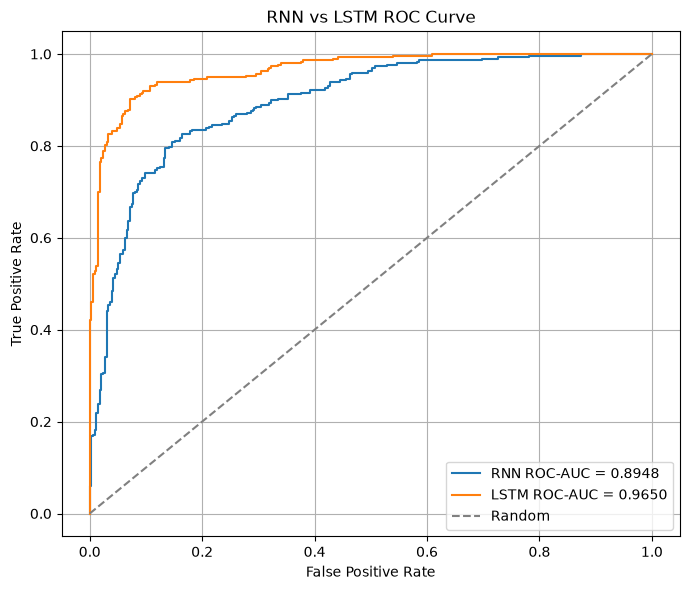

Vocab exported to: Fake_News_Model_Creator\exported_models\vocab.json
Model config exported to: Fake_News_Model_Creator\exported_models\model_config.json


,Model,Best Epoch,Best Validation ROC-AUC,Test ROC-AUC,Export Path
0,RNN,9,0.884433,0.894809,Fake_News_Model_Creator\exported_models\rnn_be...
1,LSTM,9,0.962486,0.964973,Fake_News_Model_Creator\exported_models\lstm_b...
2,Best Overall (LSTM),9,0.962486,0.964973,Fake_News_Model_Creator\exported_models\best_o...


In [66]:
import matplotlib.pyplot as plt

best_checkpoints = {
    "RNN": rnn_best_checkpoint,
    "LSTM": lstm_best_checkpoint
}

best_model_name = max(
    best_checkpoints,
    key=lambda model_name: best_checkpoints[model_name]["val_roc_auc"]
)
best_model = rnn if best_model_name == "RNN" else lstm

rnn_test_metrics = evaluate(rnn, test_loader, return_predictions=True)
lstm_test_metrics = evaluate(lstm, test_loader, return_predictions=True)
test_metrics_by_model = {
    "RNN": rnn_test_metrics,
    "LSTM": lstm_test_metrics
}

plt.figure(figsize=(7, 6))

for model_name, metrics in test_metrics_by_model.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        metrics["labels"],
        metrics["probabilities"]
    )
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} ROC-AUC = {metrics['roc_auc']:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RNN vs LSTM ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

export_dir = Path("Fake_News_Model_Creator/exported_models")
export_dir.mkdir(parents=True, exist_ok=True)

model_config = {
    "vocab_size": len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "rnn_bidirectional": False,
    "lstm_bidirectional": True,
    "pad_token": PAD_TOKEN,
    "unk_token": UNK_TOKEN,
    "pad_idx": PAD_IDX,
    "unk_idx": UNK_IDX,
    "label_mapping": {"FAKE": 0, "REAL": 1}
}

exports = {
    "rnn_best_model.pt": {
        "model_type": "RNN",
        "model_state_dict": rnn_best_checkpoint["state_dict"],
        "best_epoch": rnn_best_checkpoint["epoch"],
        "best_validation_roc_auc": rnn_best_checkpoint["val_roc_auc"],
        "test_roc_auc": rnn_test_metrics["roc_auc"],
        "config": model_config
    },
    "lstm_best_model.pt": {
        "model_type": "LSTM",
        "model_state_dict": lstm_best_checkpoint["state_dict"],
        "best_epoch": lstm_best_checkpoint["epoch"],
        "best_validation_roc_auc": lstm_best_checkpoint["val_roc_auc"],
        "test_roc_auc": lstm_test_metrics["roc_auc"],
        "config": model_config
    },
    "best_overall_model.pt": {
        "model_type": best_model_name,
        "model_state_dict": best_checkpoints[best_model_name]["state_dict"],
        "best_epoch": best_checkpoints[best_model_name]["epoch"],
        "best_validation_roc_auc": best_checkpoints[best_model_name]["val_roc_auc"],
        "test_roc_auc": test_metrics_by_model[best_model_name]["roc_auc"],
        "config": model_config
    }
}

for filename, checkpoint in exports.items():
    torch.save(checkpoint, export_dir / filename)

with open(export_dir / "vocab.json", "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, indent=2)

with open(export_dir / "model_config.json", "w", encoding="utf-8") as config_file:
    json.dump(model_config, config_file, indent=2)

export_summary = pd.DataFrame([
    {
        "Model": "RNN",
        "Best Epoch": rnn_best_checkpoint["epoch"],
        "Best Validation ROC-AUC": rnn_best_checkpoint["val_roc_auc"],
        "Test ROC-AUC": rnn_test_metrics["roc_auc"],
        "Export Path": str(export_dir / "rnn_best_model.pt")
    },
    {
        "Model": "LSTM",
        "Best Epoch": lstm_best_checkpoint["epoch"],
        "Best Validation ROC-AUC": lstm_best_checkpoint["val_roc_auc"],
        "Test ROC-AUC": lstm_test_metrics["roc_auc"],
        "Export Path": str(export_dir / "lstm_best_model.pt")
    },
    {
        "Model": f"Best Overall ({best_model_name})",
        "Best Epoch": best_checkpoints[best_model_name]["epoch"],
        "Best Validation ROC-AUC": best_checkpoints[best_model_name]["val_roc_auc"],
        "Test ROC-AUC": test_metrics_by_model[best_model_name]["roc_auc"],
        "Export Path": str(export_dir / "best_overall_model.pt")
    }
])

print("Vocab exported to:", export_dir / "vocab.json")
print("Model config exported to:", export_dir / "model_config.json")
export_summary
